In [ ]:
#Text Preprocessing Pipeline for Social Media Data

#1. INTRODUCTION

Social media data is highly unstructured and noisy. It includes
elements such as hashtags, mentions, URLs, emojis, and informal language. 

To perform meaningful analysis, it is essential to preprocess
the data and convert it into a structured format.

This project demonstrates a complete text preprocessing pipeline using a sample Twitter dataset.

In [4]:
import sys
!{sys.executable} -m pip install wordcloud

  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)


In [7]:
#2. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
#3. DOWNLOAD NLTK DATA

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
#4. LOAD DATASET

import pandas as pd
df = pd.read_csv("twitter_large_sample.csv")
df['text'] = df['text'].astype(str)

In [ ]:
#5. DATASET UNDERSTANDING

The dataset contains social media text data collected from Twitter-like content.

It includes:
- Hashtags (#loveit)
- Mentions (@user)
- URLs
- Emojis
- Informal expressions

This makes it ideal for demonstrating text preprocessing techniques.

In [10]:
#6. SAMPLE RAW DATA

for i in range(5):
    print(df['text'].iloc[i])
    print()

Check out our page #marketing

Worst service ever... totally disappointed 😡

Worst experience ever!!! 😂

Highly recommended 😊

Worst app ever, keeps crashing 😂



In [ ]:
#7. PIPELINE FLOW

#Text Preprocessing Pipeline:

Raw Text 
→ Lowercasing 
→ URL Removal 
→ Mention Removal 
→ Hashtag Processing 
→ Noise Removal 
→ Tokenization 
→ Stopword Removal 
→ Lemmatization 
→ Clean Tokens

In [11]:
#8. DEFINE PREPROCESSING FUNCTION

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    # Lowercasing
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)
    
    # Remove repeated characters
    text = re.sub(r'(.)\1+', r'\1\1', text)
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return tokens
    
   

In [12]:
#9. APPLY PIPELINE

df['tokens'] = df['text'].apply(preprocess_text)

In [13]:
#10. PIPELINE DEMONSTRATION

sample = df['text'].iloc[0]

print("Original:", sample)

step1 = sample.lower()
print("\nLowercase:", step1)

step2 = re.sub(r'http\S+|www\S+', '', step1)
print("\nAfter URL Removal:", step2)

step3 = re.sub(r'@\w+', '', step2)
print("\nAfter Mention Removal:", step3)

step4 = re.sub(r'#', '', step3)
print("\nAfter Hashtag Processing:", step4)

Original: Check out our page #marketing

Lowercase: check out our page #marketing

After URL Removal: check out our page #marketing

After Mention Removal: check out our page #marketing

After Hashtag Processing: check out our page marketing


In [26]:
#11. WORD FREQUENCY ANALYSIS

all_words = []

for tokens in df['tokens']:
    all_words.extend(tokens)

word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

common_words

[('service', 5),
 ('ever', 5),
 ('product', 4),
 ('great', 4),
 ('worst', 3),
 ('check', 3),
 ('experience', 3),
 ('happy', 3),
 ('bad', 3),
 ('money', 3)]

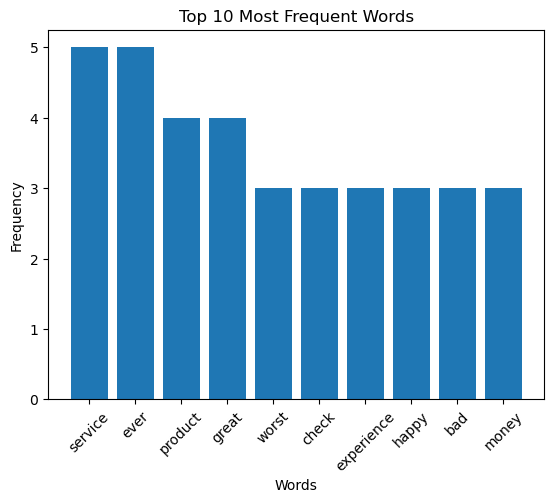

In [27]:
#12. BAR CHART VISUALIZATION

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

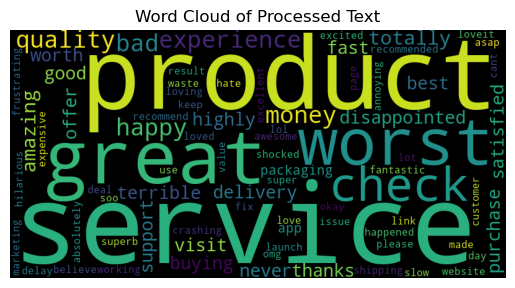

In [28]:
#13. WORD CLOUD

text_for_wc = " ".join(all_words)

wordcloud = WordCloud(width=800, height=400).generate(text_for_wc)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Processed Text")
plt.show()

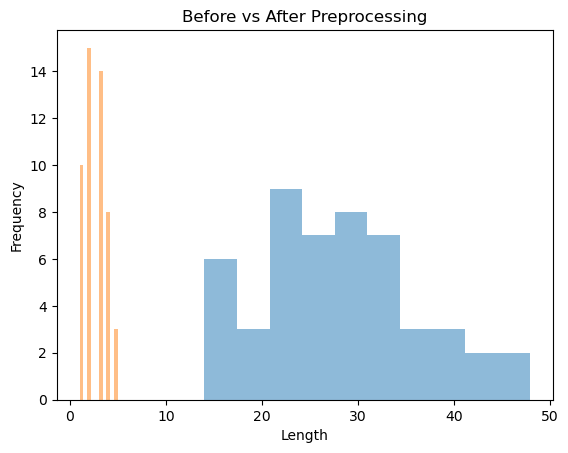

In [29]:
#14. BEFORE vs AFTER

original_lengths = df['text'].apply(len)
processed_lengths = df['tokens'].apply(len)

plt.figure()
plt.hist(original_lengths, alpha=0.5)
plt.hist(processed_lengths, alpha=0.5)
plt.title("Before vs After Preprocessing")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

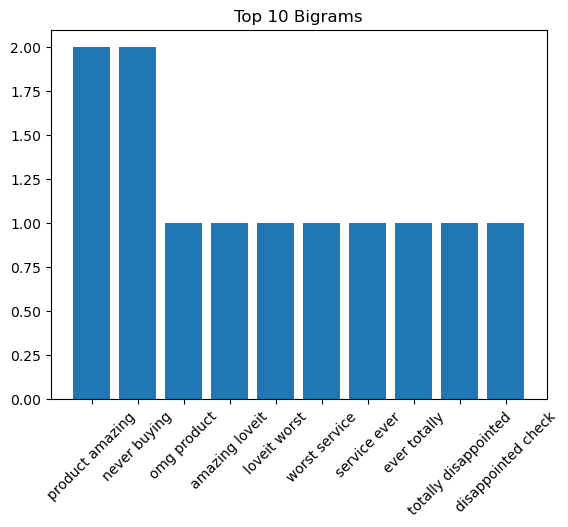

In [30]:
#15. BIGRAM ANALYSIS

from nltk.util import ngrams

bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(bigrams).most_common(10)

bigram_words = [' '.join(i[0]) for i in bigram_freq]
bigram_counts = [i[1] for i in bigram_freq]

plt.figure()
plt.bar(bigram_words, bigram_counts)
plt.xticks(rotation=45)
plt.title("Top 10 Bigrams")
plt.show()

In [31]:
#16. FINAL OUTPUT SAMPLE

for i in range(5):
    print("Original:", df['text'].iloc[i])
    print("Processed:", df['tokens'].iloc[i])
    print()

Original: OMG!!! This product is amazing ???? #loveit
Processed: ['omg', 'product', 'amazing', 'loveit']

Original: Worst service ever... totally disappointed ??
Processed: ['worst', 'service', 'ever', 'totally', 'disappointed']

Original: Check this out: https://example.com
Processed: ['check']

Original: @brand Your service is good but delivery is slow
Processed: ['service', 'good', 'delivery', 'slow']

Original: LOL ?? this made my day!!!
Processed: ['lol', 'made', 'day']



In [ ]:
#17. WHY EACH STEP

- Lowercasing: Ensures uniformity in text  
- URL Removal: Removes irrelevant links  
- Mention Removal: Eliminates usernames  
- Hashtag Processing: Keeps meaningful words  
- Tokenization: Splits text into words  
- Stopword Removal: Removes common non-informative words  
- Lemmatization: Converts words to base form  

In [ ]:
#18. LIMITATIONS

- Context such as sarcasm may be lost  
- Emojis are removed instead of interpreted  
- Slang and abbreviations may not be fully handled  

In [ ]:
#19. CONCLUSION

This project demonstrates how raw social media data can be transformed 
into a structured format using a text preprocessing pipeline.

The preprocessing steps significantly improve data quality and prepare it
for further analysis such as sentiment analysis,topic modeling or machine learning.

Visualizations provide insights into common patterns in the dataset.